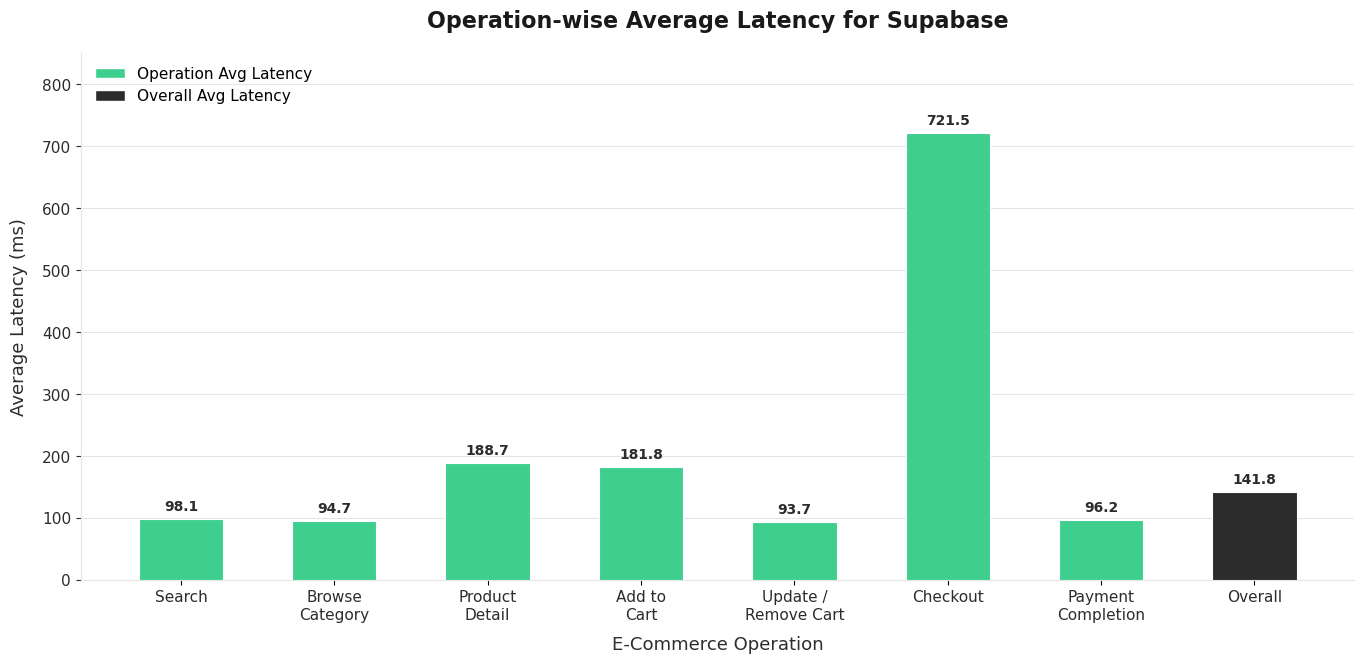

✅ Saved: supabase_latency_chart.png


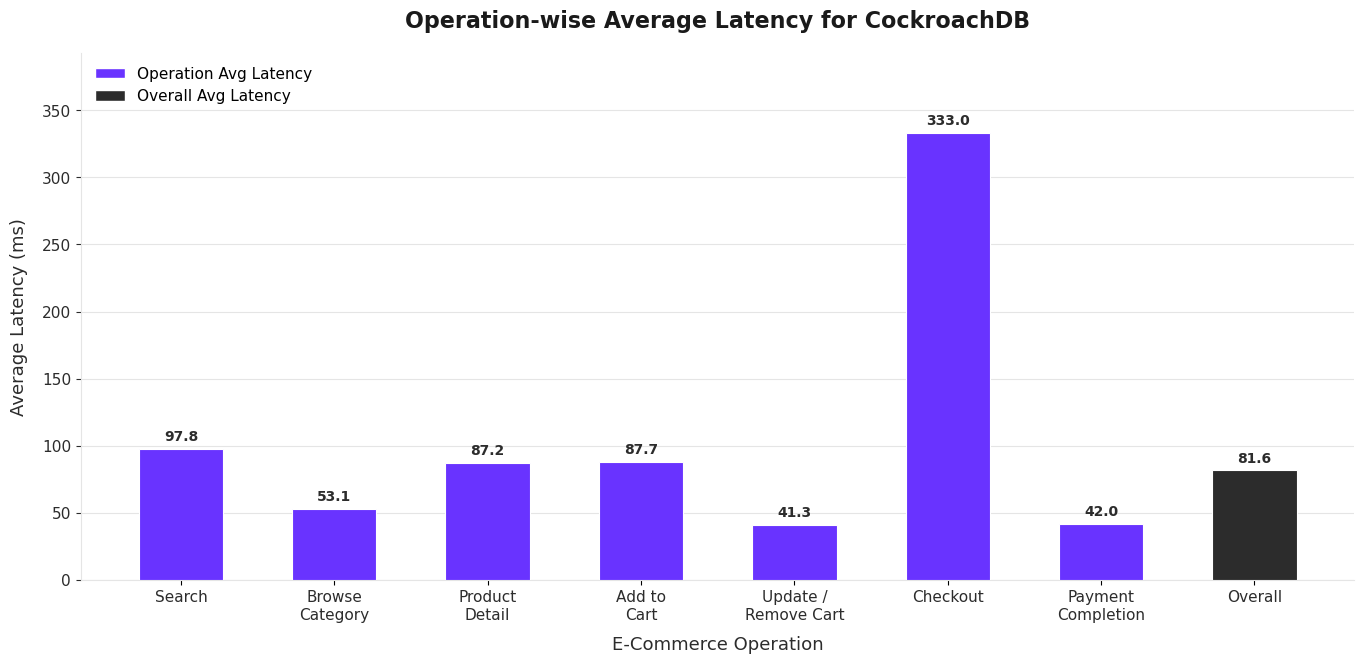

✅ Saved: cockroach_latency_chart.png


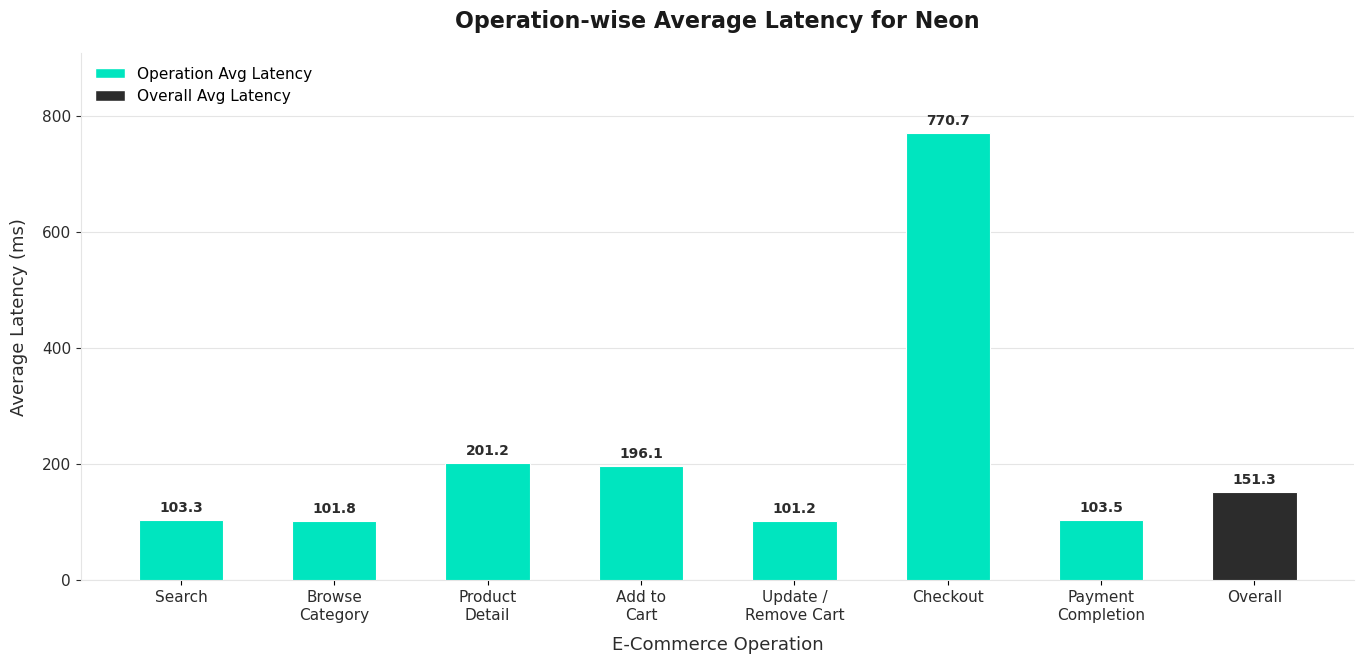

✅ Saved: neon_latency_chart.png

✅ All three charts generated and saved!


In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ============================================
# DATA
# ============================================

operations = [
    "Search",
    "Browse\nCategory",
    "Product\nDetail",
    "Add to\nCart",
    "Update /\nRemove Cart",
    "Checkout",
    "Payment\nCompletion",
    "Overall"
]

data = {
    "Supabase": {
        "avg":   [98.14, 94.72, 188.65, 181.75, 93.73, 721.46, 96.19, 141.83],
        "color": "#3ECF8E",   # Supabase green
        "filename": "supabase_latency_chart.png",
        "title": "Operation-wise Average Latency for Supabase"
    },
    "CockroachDB": {
        "avg":   [97.85, 53.15, 87.21, 87.73, 41.30, 333.00, 42.05, 81.57],
        "color": "#6933FF",   # CockroachDB purple
        "filename": "cockroach_latency_chart.png",
        "title": "Operation-wise Average Latency for CockroachDB"
    },
    "Neon": {
        "avg":   [103.33, 101.84, 201.22, 196.12, 101.24, 770.69, 103.54, 151.31],
        "color": "#00E5BF",   # Neon teal
        "filename": "neon_latency_chart.png",
        "title": "Operation-wise Average Latency for Neon"
    }
}

# ============================================
# CHART STYLE CONSTANTS
# ============================================

BAR_WIDTH       = 0.55
FIG_WIDTH       = 14
FIG_HEIGHT      = 7
DPI             = 300
FONT_FAMILY     = "DejaVu Sans"
TITLE_SIZE      = 16
AXIS_LABEL_SIZE = 13
TICK_SIZE       = 11
VALUE_LABEL_SIZE= 10
OVERALL_COLOR   = "#2C2C2C"   # Dark bar for Overall column
GRID_COLOR      = "#E5E5E5"
BG_COLOR        = "white"

plt.rcParams.update({
    "font.family":       FONT_FAMILY,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  True,
    "axes.spines.bottom":True,
})

# ============================================
# GENERATE CHARTS
# ============================================

for db_name, db_data in data.items():

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    x      = np.arange(len(operations))
    avg    = db_data["avg"]
    colors = [OVERALL_COLOR if op == "Overall" else db_data["color"] for op in operations]

    bars = ax.bar(
        x,
        avg,
        width     = BAR_WIDTH,
        color     = colors,
        edgecolor = "white",
        linewidth = 0.8,
        zorder    = 3
    )

    # ---- Value labels on top of each bar ----
    for bar, val in zip(bars, avg):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max(avg) * 0.012),
            f"{val:.1f}",
            ha        = "center",
            va        = "bottom",
            fontsize  = VALUE_LABEL_SIZE,
            fontweight= "bold",
            color     = "#2C2C2C"
        )

    # ---- Horizontal grid lines ----
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    # ---- Axes labels ----
    ax.set_xlabel(
        "E-Commerce Operation",
        fontsize  = AXIS_LABEL_SIZE,
        labelpad  = 10,
        color     = "#2C2C2C"
    )
    ax.set_ylabel(
        "Average Latency (ms)",
        fontsize  = AXIS_LABEL_SIZE,
        labelpad  = 10,
        color     = "#2C2C2C"
    )

    # ---- X-axis ticks ----
    ax.set_xticks(x)
    ax.set_xticklabels(
        operations,
        fontsize = TICK_SIZE,
        color    = "#2C2C2C"
    )

    # ---- Y-axis ticks ----
    ax.tick_params(axis='y', labelsize=TICK_SIZE, colors="#2C2C2C")

    # ---- Y-axis range with headroom for labels ----
    ax.set_ylim(0, max(avg) * 1.18)

    # ---- Title ----
    ax.set_title(
        db_data["title"],
        fontsize  = TITLE_SIZE,
        fontweight= "bold",
        pad       = 18,
        color     = "#1A1A1A"
    )

    # ---- Legend patch ----
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=db_data["color"], edgecolor="white", label="Operation Avg Latency"),
        Patch(facecolor=OVERALL_COLOR,    edgecolor="white", label="Overall Avg Latency")
    ]
    ax.legend(
        handles   = legend_elements,
        fontsize  = TICK_SIZE,
        frameon   = False,
        loc       = "upper left"
    )

    # ---- Spine styling ----
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["bottom"].set_color(GRID_COLOR)

    # ---- Tight layout & save ----
    plt.tight_layout(pad=2.0)
    plt.savefig(
        db_data["filename"],
        dpi         = DPI,
        bbox_inches = "tight",
        facecolor   = BG_COLOR
    )
    plt.show()
    print(f"✅ Saved: {db_data['filename']}")

print("\n✅ All three charts generated and saved!")